# Using the to_fits and read_generic_lightcurve functions

## Learning Goals

By the end of this tutorial you will: 

- Learn how to create a [LightCurve object](https://lightkurve.github.io/lightkurve/tutorials/1-getting-started/what-are-lightcurve-objects.html).
- Save the LightCurve object as a fits file using the [`to_fits`](https://lightkurve.github.io/lightkurve/reference/api/lightkurve.LightCurve.to_fits.html?highlight=to_fits#lightkurve.LightCurve.to_fits) function.
- Read in the same FITs file using the [`read_generic_lightcurve`](https://github.com/lightkurve/lightkurve/blob/f8e8c16ba5135b8811d908bb919815b93dcce2bd/src/lightkurve/io/generic.py#L20-L31) function.

## Introduction

The intent of the tutorial is to illustrate how one might use data from any mission (not just Kepler, K2, or TESS) and analize it within Lightkurve. 

## Imports
This tutorial requires:

- [Lightkurve](https://lightkurve.github.io/lightkurve/index.html)
- [Matplotlib](https://matplotlib.org/)
- [numpy](https://numpy.org/)
- astropy [time](https://docs.astropy.org/en/stable/time/index.html) and [units](https://docs.astropy.org/en/latest/units/index.html)

In [15]:
%matplotlib inline

import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np

from astropy.time import Time
import astropy.units as u

## 1: Creating our lightcurve data and our LightCurve Object

First we will create some fake lightcurve data to use as an example and convert this into a LightCurve Object. 
You could also download a LightCurve Object via using [`search_lightcurve`](https://lightkurve.github.io/lightkurve/reference/api/lightkurve.search_lightcurve.html?highlight=search_lightcurve#lightkurve.search_lightcurve) and [`download()`](https://lightkurve.github.io/lightkurve/reference/api/lightkurve.SearchResult.download.html?highlight=download#lightkurve.SearchResult.download) if you wish, but for now we will create our simple data set.

In [16]:
#Create the time values and specify the format
time_values = Time(np.linspace(2458000, 2458000 + 10, 100), format='jd')

#Create the flux and flux error values
flux_values = np.sin(time_values.value * 0.5) + 1000
flux_err_values = np.full_like(flux_values, 0.01, dtype=np.float32)

#Specify the flux units 
unit_flux = u.electron/u.second

Using this data set we then use the `LightCurve` function to create our object and look at the data. 

In [17]:
#Create the LightCurve object and look 
my_lc = lk.LightCurve(time=time_values, flux=flux_values * unit_flux, flux_err=flux_err_values * unit_flux)
my_lc

time,flux,flux_err
,electron / s,electron / s
Time,float64,float32
2458000.0,1000.4536549054471,0.009999999776482582
2458000.101010101,1000.4080866165767,0.009999999776482582
2458000.202020202,1000.3614776178835,0.009999999776482582
2458000.303030303,1000.3139467722524,0.009999999776482582
2458000.404040404,1000.2656152941383,0.009999999776482582
2458000.505050505,1000.2166064391281,0.009999999776482582
2458000.606060606,1000.1670451904844,0.009999999776482582
2458000.707070707,1000.1170579401942,0.009999999776482582


We can now access the column values directly as an attribute of the object. 

In [18]:
my_lc.flux

<Quantity [1000.45365491, 1000.40808662, 1000.36147762, 1000.31394677,
           1000.26561529, 1000.21660644, 1000.16704519, 1000.11705794,
           1000.06677217, 1000.01631611,  999.96581844,  999.91540795,
            999.86521318,  999.81536215,  999.76598198,  999.71719861,
            999.66913645,  999.62191806,  999.57566386,  999.53049181,
            999.48651711,  999.44385191,  999.402605  ,  999.36288158,
            999.32478295,  999.28840627,  999.25384431,  999.22118521,
            999.19051226,  999.16190367,  999.13543242,  999.111166  ,
            999.0891663 ,  999.06948943,  999.05218556,  999.03729882,
            999.02486719,  999.01492235,  999.00748968,  999.00258812,
            999.00023018,  999.00042188,  999.00316271,  999.0084457 ,
            999.01625737,  999.02657779,  999.03938065,  999.05463331,
            999.07229685,  999.09232624,  999.11467039,  999.13927233,
            999.16606931,  999.194993  ,  999.22596963,  999.25892021,
      

We can also plot the data. 

<Axes: xlabel='Time [JD]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

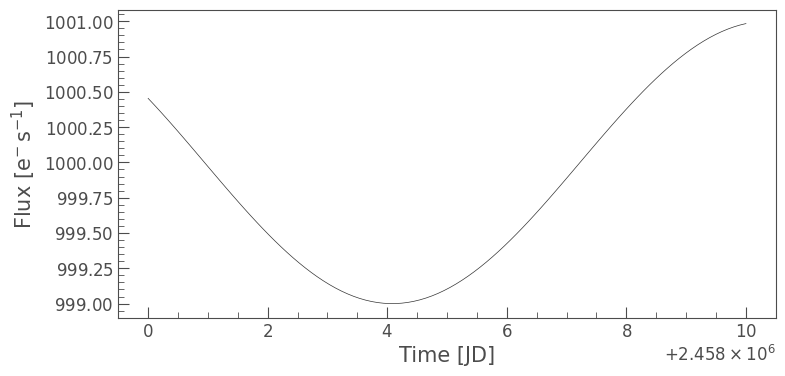

In [19]:
my_lc.plot()

Additional meta data or keyword arguments may be added via a dictionary as part of `LightCurve` function. 

For example we could define the mission and the telescope we obtained the data from via the following: 

In [20]:
my_lc.meta['TELESCOP'] = "MY_FAKE_TELESCOPE"
my_lc.meta['MISSION'] = "MY_FAKE_MISSION"
print(my_lc.meta['TELESCOP'], my_lc.meta['MISSION'])

MY_FAKE_TELESCOPE MY_FAKE_MISSION


## 2: Saving the LightCurve Object as a FITS file

We can now convert our object into a FITS file using the `to_fits` function. For this we simply need to state the file name and path.
Be sure to state if you want your file to be overwritten or not using either False or True.

In [21]:
output_filename = './my_custom_lightcurve.fits'
my_lc.to_fits(output_filename, overwrite=True)
f"LightCurve saved to {output_filename}"

'LightCurve saved to ./my_custom_lightcurve.fits'

Note we can also add information to our fits file using an extra_data dictionary. Defined extra keywords or columns would then be included in the FITS file. Keywords would be stroed in the primary header and np.array data as columns in the 1st extension. As an example let's add an "ORIGIN" keyword which will indicate where got our data from.

In [22]:
extra_data = {"ORIGIN": "Tutorial"}

We can then overwrite our old file and add this so when we read it in, it will be there.

In [23]:
my_lc.to_fits(output_filename, overwrite=True, **extra_data)

[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x1687bb440>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x16890c2f0>]

## 3: Reading in a FITS file

We can now use the `read_generic_lightcurve` funtion to read in our FITS file as a LightCurve Object. To do this we must specify the file and the relevent columns for our data.

In [24]:
read_lc = lk.io.generic.read_generic_lightcurve(filename='./my_custom_lightcurve.fits', time_column="time", flux_column="flux", flux_err_column="flux_err", time_format="jd")

We can now query the object as done previously.

In [25]:
read_lc

time,flux,flux_err
,electron / s,electron / s
Time,float32,float32
2458000.0,1000.4536743164062,0.009999999776482582
2458000.101010101,1000.4080810546875,0.009999999776482582
2458000.202020202,1000.3614501953125,0.009999999776482582
2458000.303030303,1000.31396484375,0.009999999776482582
2458000.404040404,1000.265625,0.009999999776482582
2458000.505050505,1000.2166137695312,0.009999999776482582
2458000.606060606,1000.1670532226562,0.009999999776482582
2458000.707070707,1000.1170654296875,0.009999999776482582


In [26]:
read_lc.flux

<Quantity [1000.4537 , 1000.4081 , 1000.36145, 1000.31396, 1000.2656 ,
           1000.2166 , 1000.16705, 1000.11707, 1000.0668 , 1000.0163 ,
            999.9658 ,  999.9154 ,  999.86523,  999.81537,  999.766  ,
            999.7172 ,  999.6691 ,  999.62195,  999.5757 ,  999.5305 ,
            999.4865 ,  999.44385,  999.4026 ,  999.36285,  999.32477,
            999.2884 ,  999.25385,  999.2212 ,  999.1905 ,  999.1619 ,
            999.13544,  999.11115,  999.0892 ,  999.0695 ,  999.0522 ,
            999.0373 ,  999.02484,  999.0149 ,  999.0075 ,  999.00256,
            999.00024,  999.0004 ,  999.0032 ,  999.0084 ,  999.01624,
            999.02655,  999.03937,  999.0546 ,  999.0723 ,  999.09235,
            999.1147 ,  999.1393 ,  999.1661 ,  999.195  ,  999.22595,
            999.2589 ,  999.29376,  999.3304 ,  999.3688 ,  999.4087 ,
            999.4502 ,  999.49304,  999.53723,  999.5826 ,  999.62897,
            999.67633,  999.7245 ,  999.7734 ,  999.8228 ,  999.87274,
      

<Axes: xlabel='Time [JD]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

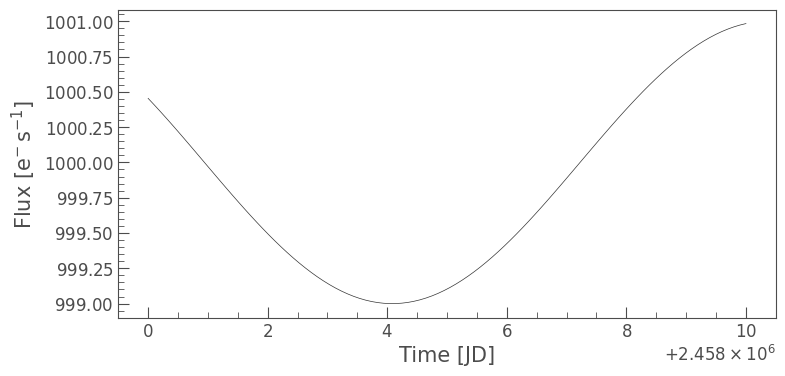

In [27]:
read_lc.plot()

We can even check the meta data to make sure our telescope, mission, and origin information was saved correctly.

In [28]:
read_lc.meta

{'EXTNAME': 'PRIMARY',
 'CHECKSUM': 'AaAiBX9ZAaAfAU7Z',
 'DATASUM': '0',
 'SIMPLE': True,
 'BITPIX': 8,
 'NAXIS': 0,
 'EXTEND': True,
 'NEXTEND': 2,
 'EXTVER': 1,
 'ORIGIN': 'Tutorial',
 'DATE': '2026-03-04',
 'CREATOR': 'lightkurve.LightCurve.to_fits()',
 'TELESCOP': 'MY_FAKE_TELESCOPE',
 'INSTRUME': None,
 'OBJECT': None,
 'RADESYS': 'ICRS',
 'RA_OBJ': None,
 'DEC_OBJ': None,
 'EQUINOX': 2000.0,
 'PROCVER': '2.5.2dev',
 'MISSION': 'MY_FAKE_MISSION',
 'LABEL': None,
 'RA': None,
 'DEC': None,
 'FILENAME': './my_custom_lightcurve.fits',
 'FLUX_ORIGIN': 'lightkurve.LightCurve.to_fits()'}

We now know how to create a LightCurve Object, save it as a FITS file, and read in a FITS file as a LightCurve Object.